In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, confusion_matrix, classification_report

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [3]:
df = pd.read_csv("iris.csv")
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [ ]:
df.info()

In [8]:
X_raw   = df.iloc[:, :-1].values

In [16]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
 
print("=== Veri Özeti ===")
print(f"Örneklem sayısı : {X.shape[0]}")
print(f"Özellik sayısı  : {X.shape[1]}")

=== Veri Özeti ===
Örneklem sayısı : 150
Özellik sayısı  : 4


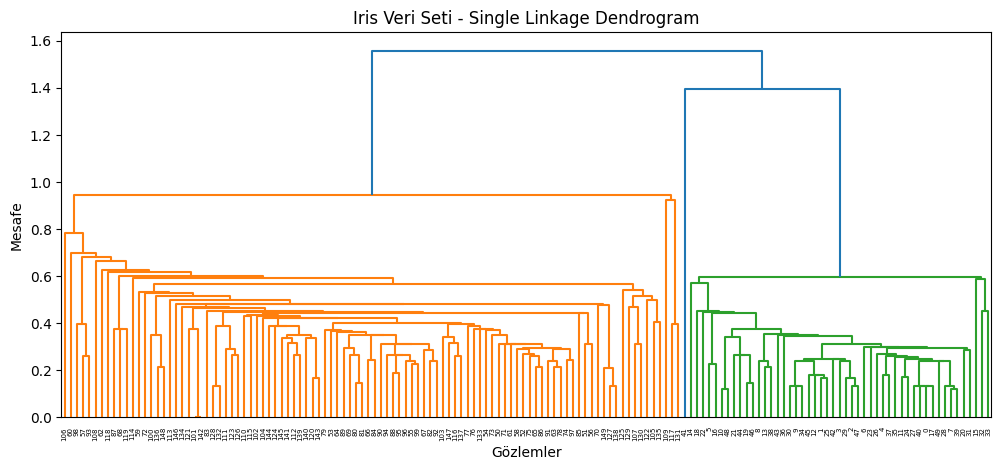

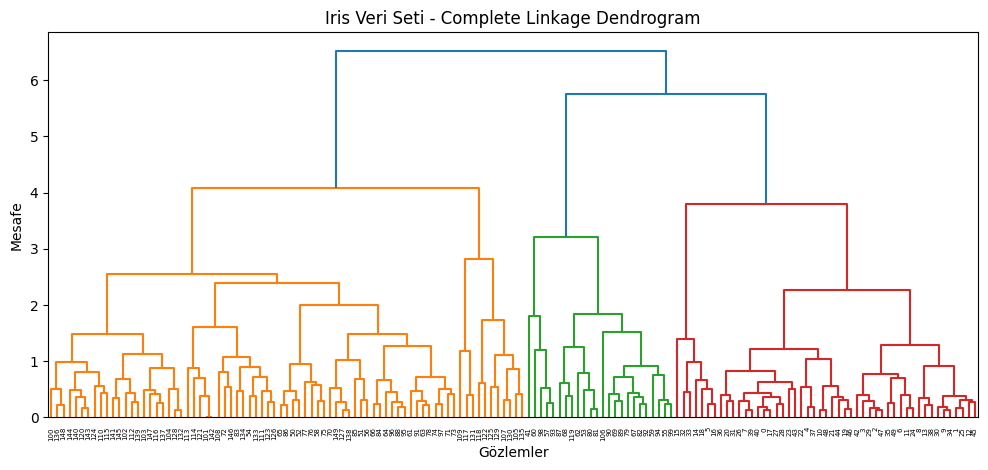

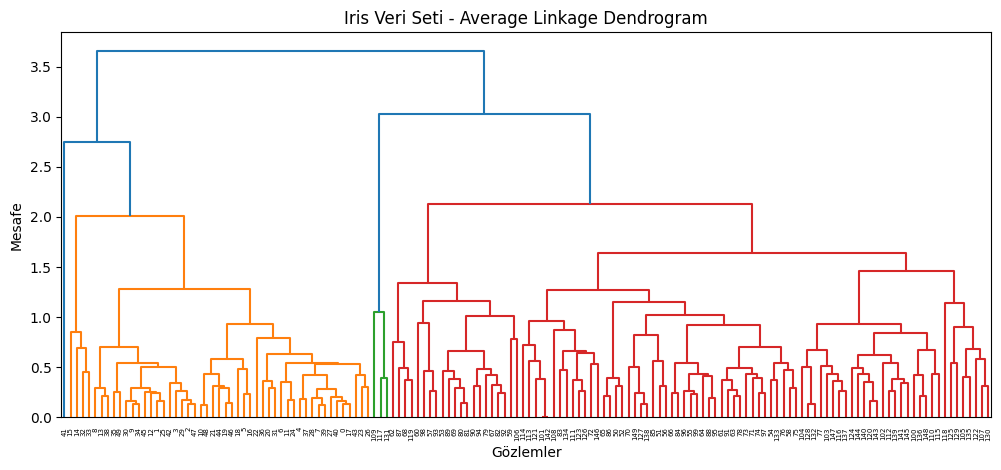

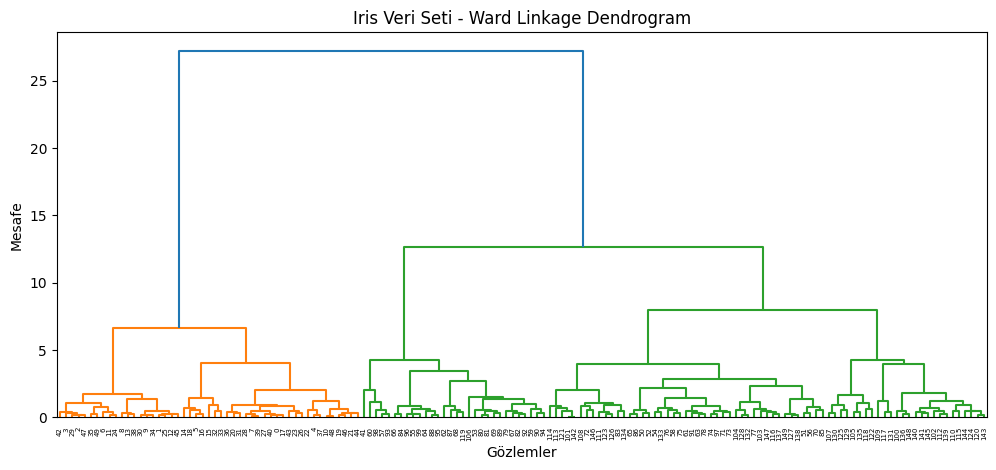

In [17]:
linkage_methods = ["single", "complete", "average", "ward"]

for method in linkage_methods:
    Z = linkage(X, method=method)
    
    plt.figure(figsize=(12, 5))
    dendrogram(Z)
    plt.title(f"Iris Veri Seti - {method.capitalize()} Linkage Dendrogram")
    plt.xlabel("Gözlemler")
    plt.ylabel("Mesafe")
    plt.show()

In [18]:
results = []

for method in linkage_methods:
    Z = linkage(X, method=method)
    
    for k in range(2, 11):
        clusters = fcluster(Z, t=k, criterion="maxclust")
        
        sil = silhouette_score(X, clusters)
        db = davies_bouldin_score(X, clusters)
        ch = calinski_harabasz_score(X, clusters)
        
        results.append({
            "Linkage": method,
            "k": k,
            "Silhouette Score": sil,
            "Davies-Bouldin Index": db,
            "Calinski-Harabasz Score": ch
        })

results_df = pd.DataFrame(results)

results_df

,Linkage,k,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,single,2,0.581750,0.593313,251.349339
1,single,3,0.504646,0.492925,131.535896
2,single,4,0.406746,0.502445,104.291513
3,single,5,0.342409,0.466173,78.115487
4,single,6,0.201887,0.498748,63.651558
5,single,7,0.205001,0.477640,55.866627
6,single,8,0.228753,0.470630,53.955824
7,single,9,0.129099,0.565912,47.380497
8,single,10,0.125794,0.558607,43.142945
9,complete,2,0.440812,0.892730,151.633173


In [19]:
results_df.sort_values(by="Silhouette Score", ascending=False).head(10)

,Linkage,k,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,single,2,0.581750,0.593313,251.349339
18,average,2,0.581750,0.593313,251.349339
27,ward,2,0.577035,0.591656,240.245665
1,single,3,0.504646,0.492925,131.535896
19,average,3,0.480267,0.575269,149.025799
10,complete,3,0.449618,0.758358,213.081710
28,ward,3,0.446689,0.803467,222.719164
9,complete,2,0.440812,0.892730,151.633173
11,complete,4,0.410607,0.876833,183.968203
20,average,4,0.406746,0.502445,104.291513


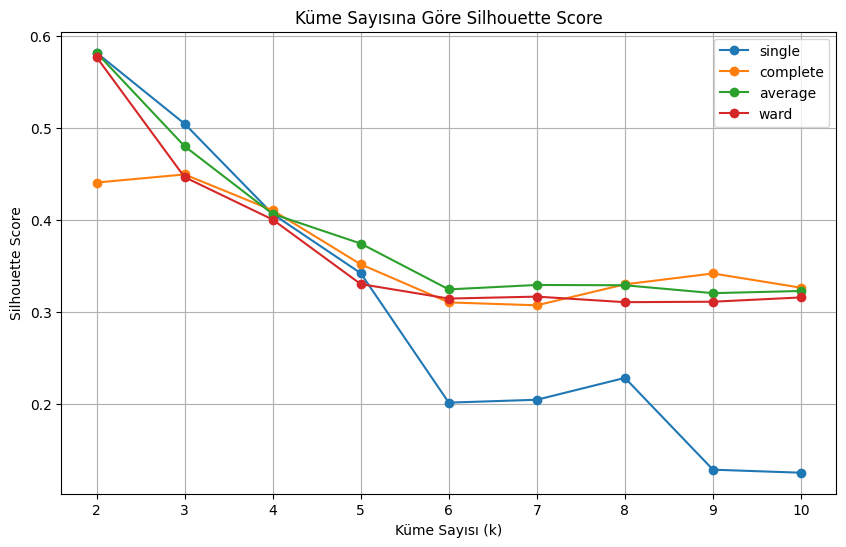

In [20]:
plt.figure(figsize=(10, 6))

for method in linkage_methods:
    subset = results_df[results_df["Linkage"] == method]
    plt.plot(subset["k"], subset["Silhouette Score"], marker="o", label=method)

plt.title("Küme Sayısına Göre Silhouette Score")
plt.xlabel("Küme Sayısı (k)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
best_result = results_df.sort_values(by="Silhouette Score", ascending=False).iloc[0]

best_method = best_result["Linkage"]
best_k = int(best_result["k"])

print("En iyi bağlantı yöntemi:", best_method)
print("Optimal küme sayısı:", best_k)
print("Silhouette Score:", best_result["Silhouette Score"])
print("Davies-Bouldin Index:", best_result["Davies-Bouldin Index"])
print("Calinski-Harabasz Score:", best_result["Calinski-Harabasz Score"])

En iyi bağlantı yöntemi: single
Optimal küme sayısı: 2
Silhouette Score: 0.5817500491982808
Davies-Bouldin Index: 0.5933126905762434
Calinski-Harabasz Score: 251.34933946458113


In [22]:
Z_best = linkage(X, method=best_method)
final_clusters = fcluster(Z_best, t=best_k, criterion="maxclust")

df_copy = df.copy()
df_copy["Cluster"] = final_clusters
df_copy.head()

,sepal.length,sepal.width,petal.length,petal.width,variety,Cluster
0,5.1,3.5,1.4,0.2,Setosa,2
1,4.9,3.0,1.4,0.2,Setosa,2
2,4.7,3.2,1.3,0.2,Setosa,2
3,4.6,3.1,1.5,0.2,Setosa,2
4,5.0,3.6,1.4,0.2,Setosa,2


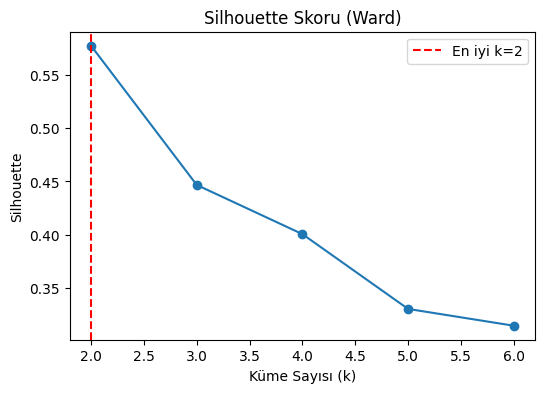

In [24]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt

Z = linkage(X, method='ward')

k_values = range(2, 7)
sil_scores = []

for k in k_values:
    clusters = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(X, clusters)
    sil_scores.append(score)

best_k = k_values[sil_scores.index(max(sil_scores))]

plt.figure(figsize=(6,4))
plt.plot(k_values, sil_scores, marker='o')
plt.axvline(best_k, linestyle='--', color='red', label=f'En iyi k={best_k}')
plt.title("Silhouette Skoru (Ward)")
plt.xlabel("Küme Sayısı (k)")
plt.ylabel("Silhouette")
plt.legend()
plt.show()

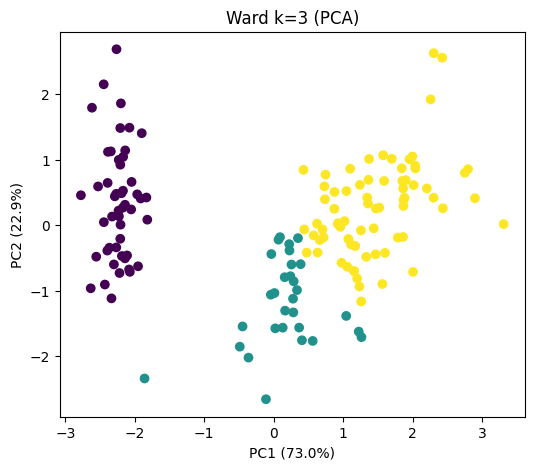

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# k=3 seçiyoruz (bilerek!)
clusters = fcluster(Z, 3, criterion='maxclust')

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Ward k=3 (PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.show()

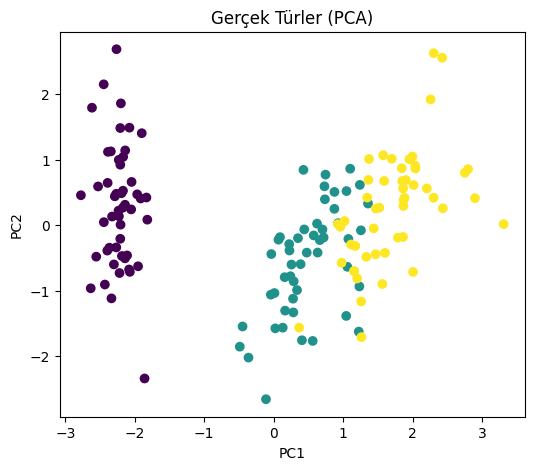

In [26]:
plt.figure(figsize=(6,5))
y_true = df['variety'].map({'Setosa': 0, 'Versicolor': 1, 'Virginica': 2})
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_true)
plt.title("Gerçek Türler (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
import pandas as pd
comparison = pd.crosstab(clusters, y_true)
print(comparison)
accuracy = np.sum(np.max(comparison.values, axis=1)) / np.sum(comparison.values)
print("Doğruluk:", accuracy)

df_clustered = df.copy()
df_clustered["Cluster"] = clusters
cluster_means = df_clustered.groupby("Cluster").mean(numeric_only=True)
print(cluster_means)

import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(cluster_means, annot=True, cmap="YlOrBr")
plt.title("Küme x Özellik Ortalamaları")
plt.show()

variety   0   1   2
row_0              
1        49   0   0
2         1  27   2
3         0  23  48
Doğruluk: 0.8266666666666667


TypeError: agg function failed [how->mean,dtype->object]